# Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import gc
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

# Config

In [16]:
class CFG:
    # Paths
    COMP_DIR = "/tmp/cassava-leaf-disease-classification"
    TRAIN_CSV = os.path.join(COMP_DIR, "train.csv")
    SAMPLE_SUB_CSV = os.path.join(COMP_DIR, "sample_submission.csv")
    TRAIN_DIR = os.path.join(COMP_DIR, "train_images")
    TEST_DIR = os.path.join(COMP_DIR, "test_images")
    LABEL_MAP_JSON = os.path.join(COMP_DIR, "label_num_to_disease_map.json")

    # General
    SEED = 42
    NUM_CLASSES = 5
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 4
    EPOCHS = 10

    # Optimization
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTHING = 0.1

    # Device
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Saving
    MODEL_PATH = "/content/drive/MyDrive/best_resnet50_cassava.pth"
    SUB_PATH = "/content/drive/MyDrive/submission.csv"

print("Device:", CFG.DEVICE)

Device: cuda


# Seed everything

In [17]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.SEED)

## Unzip Dataset

In [18]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/cassava-leaf-disease-classification.zip'
extract_dir = '/tmp/cassava-leaf-disease-classification'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset unzipped to: {extract_dir}")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba3b7630400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

# Load data

In [19]:
train_df = pd.read_csv(CFG.TRAIN_CSV)
sample_sub = pd.read_csv(CFG.SAMPLE_SUB_CSV)

print("Train shape:", train_df.shape)
print(train_df.head())

with open(CFG.LABEL_MAP_JSON, "r") as f:
    label_map = json.load(f)

print("Label map:", label_map)
print("\nClass counts:")
print(train_df["label"].value_counts().sort_index())

Train shape: (21397, 2)
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3
Label map: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}

Class counts:
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64


# Train/Validation split

In [20]:
train_df["image_path"] = train_df["image_id"].apply(lambda x: os.path.join(CFG.TRAIN_DIR, x))

train_fold, valid_fold = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=CFG.SEED
)

train_fold = train_fold.reset_index(drop=True)
valid_fold = valid_fold.reset_index(drop=True)

print("Train split:", train_fold.shape)
print("Valid split:", valid_fold.shape)

print("\nTrain label distribution:")
print(train_fold["label"].value_counts(normalize=True).sort_index())

print("\nValid label distribution:")
print(valid_fold["label"].value_counts(normalize=True).sort_index())

Train split: (17117, 3)
Valid split: (4280, 3)

Train label distribution:
label
0    0.050827
1    0.102296
2    0.111527
3    0.614944
4    0.120407
Name: proportion, dtype: float64

Valid label distribution:
label
0    0.050701
1    0.102336
2    0.111449
3    0.614953
4    0.120561
Name: proportion, dtype: float64


# Transforms

In [21]:
train_transforms = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32)),
    transforms.RandomResizedCrop(CFG.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value='random')
])

valid_transforms = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset class

In [22]:
class CassavaDataset(Dataset):
    def __init__(self, df=None, img_dir=None, transforms=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transforms = transforms
        self.is_test = is_test

        if self.is_test:
            self.image_ids = sorted(os.listdir(img_dir))
        else:
            self.image_paths = df["image_path"].values
            self.labels = df["label"].values

    def __len__(self):
        if self.is_test:
            return len(self.image_ids)
        return len(self.df)

    def __getitem__(self, idx):
        if self.is_test:
            image_id = self.image_ids[idx]
            image_path = os.path.join(self.img_dir, image_id)
            image = Image.open(image_path).convert("RGB")

            if self.transforms:
                image = self.transforms(image)

            return image, image_id

        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transforms:
            image = self.transforms(image)

        return image, torch.tensor(label, dtype=torch.long)

# DataLoaders

In [23]:
train_dataset = CassavaDataset(
    df=train_fold,
    transforms=train_transforms,
    is_test=False
)

valid_dataset = CassavaDataset(
    df=valid_fold,
    transforms=valid_transforms,
    is_test=False
)

test_dataset = CassavaDataset(
    img_dir=CFG.TEST_DIR,
    transforms=valid_transforms,
    is_test=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 535
Valid batches: 134
Test batches: 1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Build ResNet50 model

In [24]:
def build_model(num_classes=5):
    # Load ResNet50 with ImageNet pre-trained weights
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    # Replace the final fully connected layer for the new number of classes
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_model(CFG.NUM_CLASSES).to(CFG.DEVICE)

print("Model initialized with ImageNet pre-trained weights.")
print(model.fc)

Model initialized with ImageNet pre-trained weights.
Linear(in_features=2048, out_features=5, bias=True)


# Loss, optimizer, scheduler

In [25]:
criterion = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS
)

# Training and validation functions

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, total=len(loader), desc="Training", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, total=len(loader), desc="Validation", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# Train loop

In [27]:
best_val_acc = 0.0
history = []

for epoch in range(CFG.EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{CFG.EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, CFG.DEVICE
    )

    val_loss, val_acc = valid_one_epoch(
        model, valid_loader, criterion, CFG.DEVICE
    )

    scheduler.step()

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"]
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CFG.MODEL_PATH)
        print(f"Best model saved to: {CFG.MODEL_PATH}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Epoch [1/10]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training:   0%|          | 0/535 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Validation:   0%|          | 0/134 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training:   0%|          | 0/535 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Validation:   0%|          | 0/134 [00:00<?, ?it/s]

Train Loss: 0.6076 | Train Acc: 0.8962
Valid Loss: 0.6927 | Valid Acc: 0.8598
LR: 0.000000
Best model saved to: /content/drive/MyDrive/best_resnet50_cassava.pth

Best Validation Accuracy: 0.8598


# Training history

In [28]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,val_loss,val_acc,lr
0,1,0.885846,0.758778,0.793565,0.809346,0.000098
1,2,0.784746,0.808494,0.754168,0.831075,0.000090
2,3,0.747131,0.827481,0.754966,0.831308,0.000079
3,4,0.725116,0.839107,0.729989,0.837850,0.000065
4,5,0.703660,0.847462,0.713658,0.848131,0.000050
5,6,0.679301,0.859204,0.696036,0.857944,0.000035
6,7,0.658809,0.872641,0.705715,0.848598,0.000021
7,8,0.636286,0.881054,0.687974,0.857710,0.000010
8,9,0.619872,0.888882,0.697353,0.857243,0.000002
9,10,0.607609,0.896244,0.692672,0.859813,0.000000


## Training History Plots (Retry)

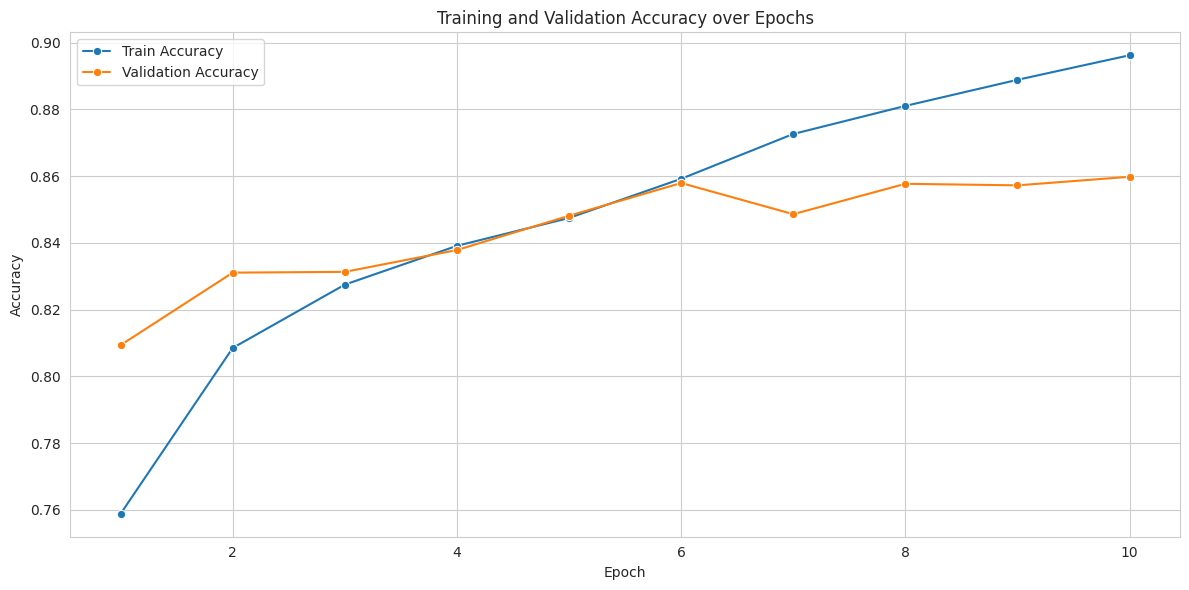

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=history_df, x='epoch', y='train_acc', label='Train Accuracy', marker='o')
sns.lineplot(data=history_df, x='epoch', y='val_acc', label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

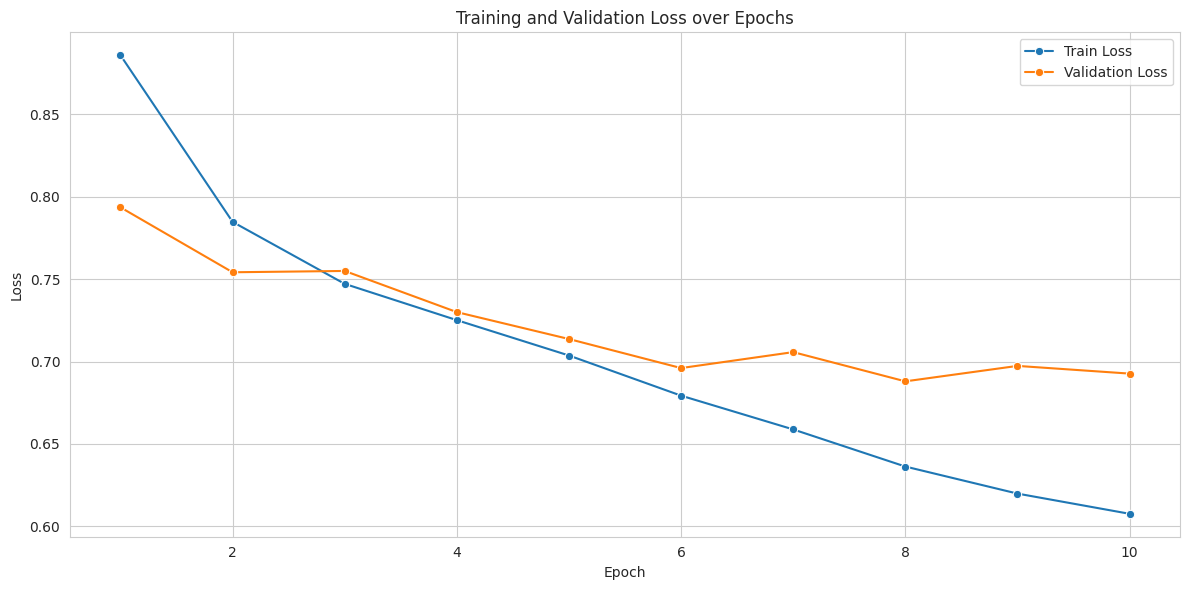

In [36]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=history_df, x='epoch', y='train_loss', label='Train Loss', marker='o')
sns.lineplot(data=history_df, x='epoch', y='val_loss', label='Validation Loss', marker='o')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Training History Plots

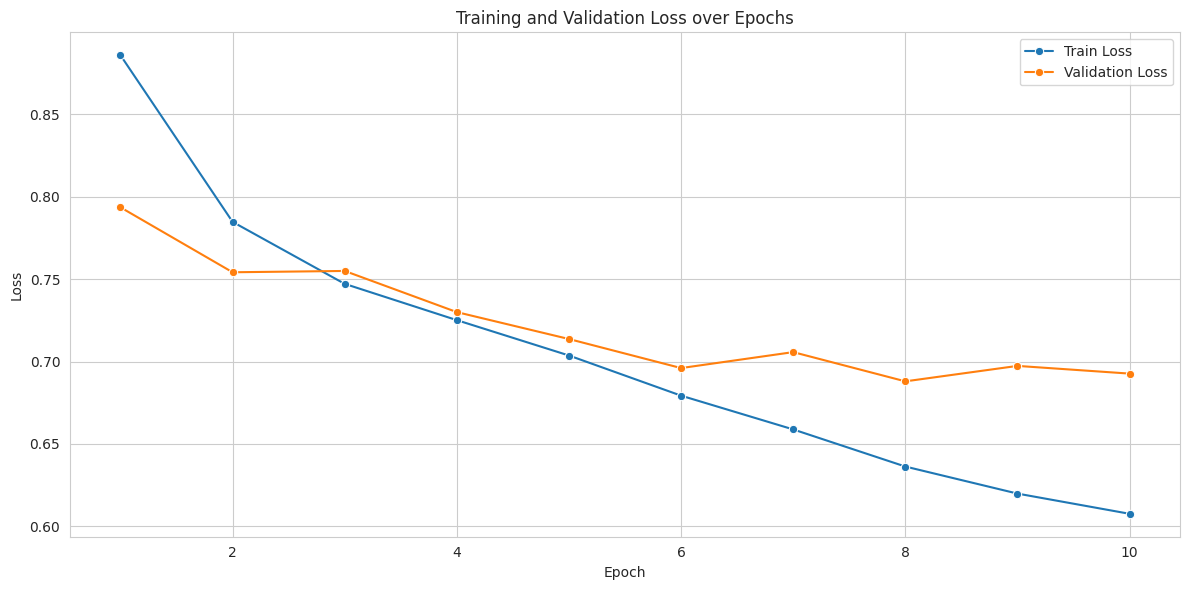

In [34]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=history_df, x='epoch', y='train_loss', label='Train Loss', marker='o')
sns.lineplot(data=history_df, x='epoch', y='val_loss', label='Validation Loss', marker='o')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Load best model

In [29]:
best_model = build_model(CFG.NUM_CLASSES).to(CFG.DEVICE)
best_model.load_state_dict(torch.load(CFG.MODEL_PATH, map_location=CFG.DEVICE))
best_model.eval()

print("Best model loaded.")

Best model loaded.


# Test prediction

In [30]:
@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()

    image_ids = []
    preds_all = []

    pbar = tqdm(loader, total=len(loader), desc="Predicting Test")

    for images, batch_image_ids in pbar:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()

        image_ids.extend(batch_image_ids)
        preds_all.extend(preds)

    return image_ids, preds_all

test_image_ids, test_preds = predict_test(best_model, test_loader, CFG.DEVICE)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Predicting Test:   0%|          | 0/1 [00:00<?, ?it/s]

# Create submission

In [31]:
submission = pd.DataFrame({
    "image_id": test_image_ids,
    "label": test_preds
})

submission = submission.sort_values("image_id").reset_index(drop=True)
submission.to_csv(CFG.SUB_PATH, index=False)

print(submission.head())
print(f"\nSubmission saved to: {CFG.SUB_PATH}")

         image_id  label
0  2216849948.jpg      4

Submission saved to: /content/drive/MyDrive/submission.csv


# Quick check

In [32]:
sub_check = pd.read_csv(CFG.SUB_PATH)
print(sub_check.shape)
print(sub_check.head())

(1, 2)
         image_id  label
0  2216849948.jpg      4


## Confusion Matrix

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Getting predictions for Confusion Matrix:   0%|          | 0/134 [00:00<?, ?it/s]

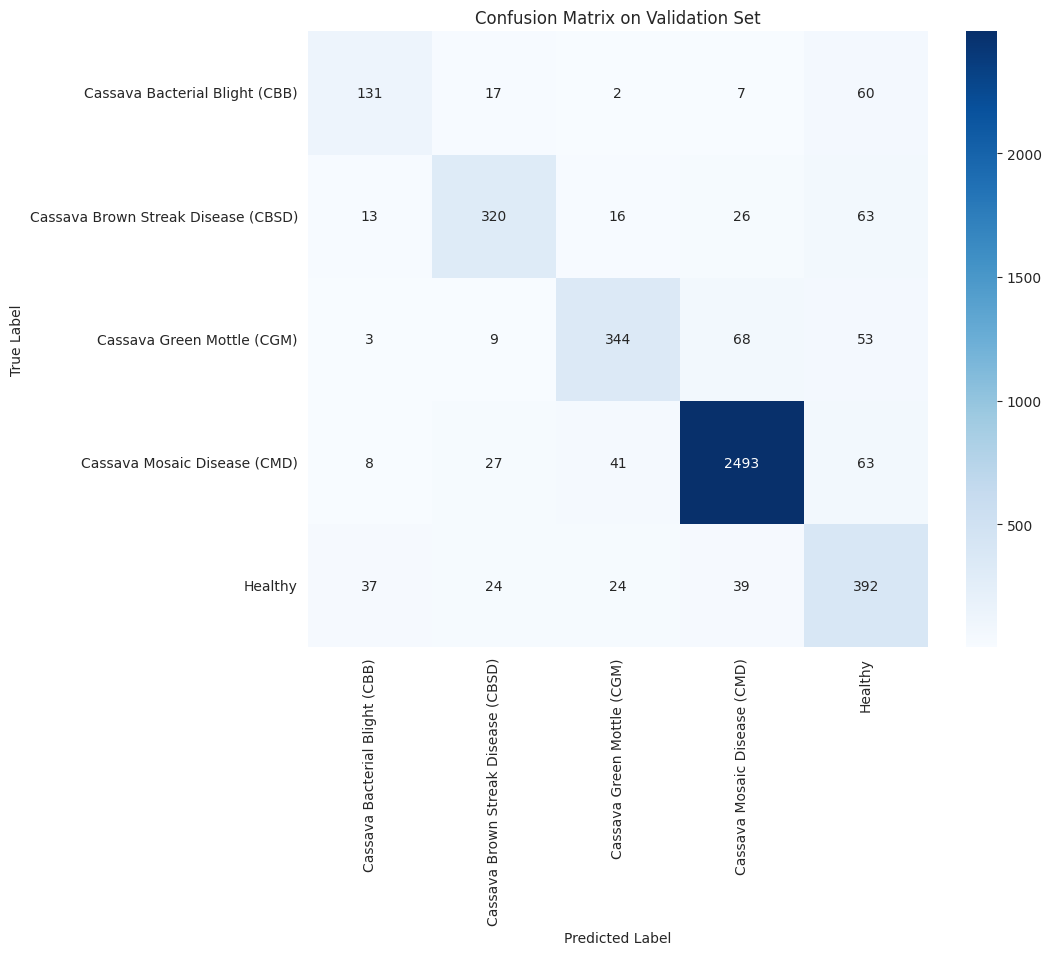

In [37]:
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in tqdm(loader, desc="Getting predictions for Confusion Matrix"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

val_preds, val_true_labels = get_predictions_and_labels(best_model, valid_loader, CFG.DEVICE)

# Generate confusion matrix
cm = confusion_matrix(val_true_labels, val_preds)

# Load label names from the label_map
label_names = [label_map[str(i)] for i in sorted(map(int, label_map.keys()))]

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Validation Set')
plt.show()

## Test with 5 Random Images

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba3b7630400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

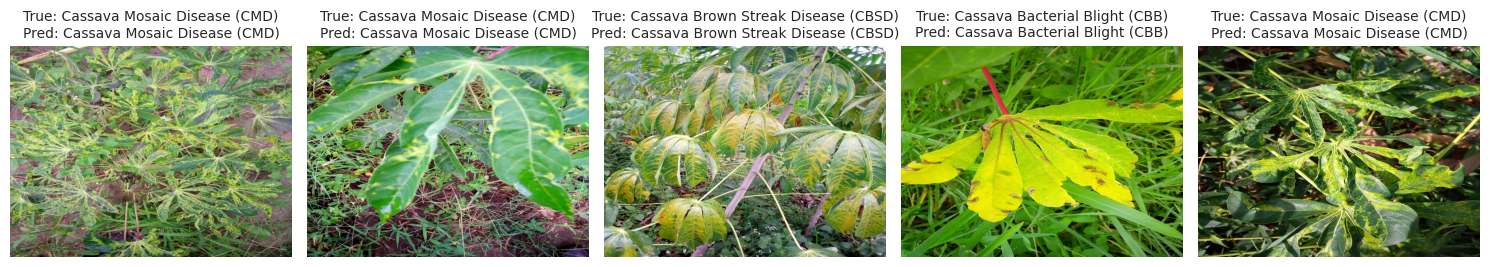

In [40]:
import matplotlib.pyplot as plt

# Select 5 random image paths from the training dataframe
random_indices = np.random.choice(len(train_df), 5, replace=False)
random_samples = train_df.iloc[random_indices]

plt.figure(figsize=(15, 10))

for i, (idx, row) in enumerate(random_samples.iterrows()):
    image_path = row['image_path']
    true_label_id = row['label']
    true_label_name = label_map[str(true_label_id)]

    image = Image.open(image_path).convert("RGB")
    transformed_image = valid_transforms(image).unsqueeze(0).to(CFG.DEVICE)

    # Make prediction
    with torch.no_grad():
        output = best_model(transformed_image)
        predicted_label_id = output.argmax(dim=1).item()
        predicted_label_name = label_map[str(predicted_label_id)]

    # Display image and prediction
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()